# Задача 2. Сегментация пользователей на основе их поведения

> Наша вторая задача состоит в том, чтобы узнать, какие вообще у нас **пользователи**, и **сегментировать** их относительно их **поведения**. Далее на основе этого сформировать **рекомендации по персонализации и удержанию** пользователей

Для сегментации пользователей будем использовать **RFM-анализ** - анализ на основе давности последней покупки (**Recency**), частоте покупок (**Frequency**) и сумме покупок (**Monetary**). Так как мы имеем данные только за 2 месяца, этого не достаточно для оценки частоты покупок, поэтому за значение Frequency будем принимать общее количество покупок.

## Подготовка данных

Импортируем все необходимые нам библиотеки и подключаем Google Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузим файл и вспомним, как выглядят наши данные:

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/analytics_project/cleaned_sample_purchases.csv')
display(df.head())

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,price_segment
0,2019-10-01 02:38:53+00:00,purchase,26201191,2.053014e+18,unknown,lucente,90.61,538338145,69c1511c-d15d-4358-8623-2ff7061d43e2,$50-100
1,2019-10-01 03:03:16+00:00,purchase,1004870,2.053014e+18,electronics.smartphone,samsung,286.86,551343044,a1ba2d90-c129-40d4-bf0d-eba7f3f9e321,$200-500
2,2019-10-01 03:10:26+00:00,purchase,1004870,2.053014e+18,electronics.smartphone,samsung,286.86,555148121,60747367-0566-4965-b8f6-fbb1e59e283d,$200-500
3,2019-10-01 03:11:54+00:00,purchase,1004856,2.053014e+18,electronics.smartphone,samsung,130.76,525921810,4454bd5f-d19a-45ab-9580-de392e690c67,$100-200
4,2019-10-01 03:36:30+00:00,purchase,26202832,2.053014e+18,unknown,efremov,112.23,534766227,52f64243-3cba-4420-bcc5-8a1e55051ad3,$100-200


## Агрегация данных по пользователям

Для RFM-анализа нам понадобится агрегировать данные по трем метрикам:
- Recency - возьмем разницу между первой датой за пределами нашего датафрейма (01.12.2019), и последней датой покупки у каждого пользователя
- Frequency - общее количество покупок за весь период
- Monetary - общая сумма покупок за весь период

In [ ]:
# для агрегации будем использовать сводную таблицу
# находим по каждому пользователю его Recency, Frequency и Monetary

rfm_df = pd.pivot_table(
    df,
    index='user_id',
    aggfunc={
        'event_time': 'max',
        'price': 'sum',
        'product_id': 'count'
    }
)
rfm_df.rename(columns={'event_time': 'last_purchase',
                       'price': 'monetary',
                       'product_id': 'frequency'}, inplace=True)
rfm_df.reset_index(inplace=True)

# задаем временную отметку, относительно которой считаем давность последней покупки
end_date = pd.Timestamp('2019-12-01', tz='UTC')
rfm_df['last_purchase'] = pd.to_datetime(rfm_df['last_purchase'], utc=True)
rfm_df['recency'] = (end_date - rfm_df['last_purchase']).dt.days
rfm_df.drop(columns=['last_purchase'], inplace=True)

# подсчитаем также общее количество пользователей
users_total = rfm_df['user_id'].count()

print(f'Всего пользователей: {users_total}')
print('\nСводная таблица для RFM-анализа:')
display(rfm_df.head())

Всего пользователей: 2312

Сводная таблица для RFM-анализа:


,user_id,monetary,frequency,recency
0,427908425,74.13,1,54
1,491929644,250.82,1,48
2,492719150,1691.92,1,34
3,502778793,949.29,2,6
4,512364781,1996.66,6,35


## Ранжирование пользователей по RFM-метрикам

Посмотрим на распределение значений по каждому параметру, чтобы понять форму данных и принять решение о способе определения интервалов:

Основные статистические характеристики RFM-метрик:


,recency,frequency,monetary
count,2312.000000,2312.000000,2312.000000
mean,29.805796,2.426471,724.107418
std,17.611778,3.350924,1679.312448
min,0.000000,1.000000,3.860000
25%,13.000000,1.000000,123.295000
50%,31.000000,1.000000,271.385000
75%,45.000000,3.000000,723.970000
max,60.000000,50.000000,47882.580000



Распределение значений метрик:


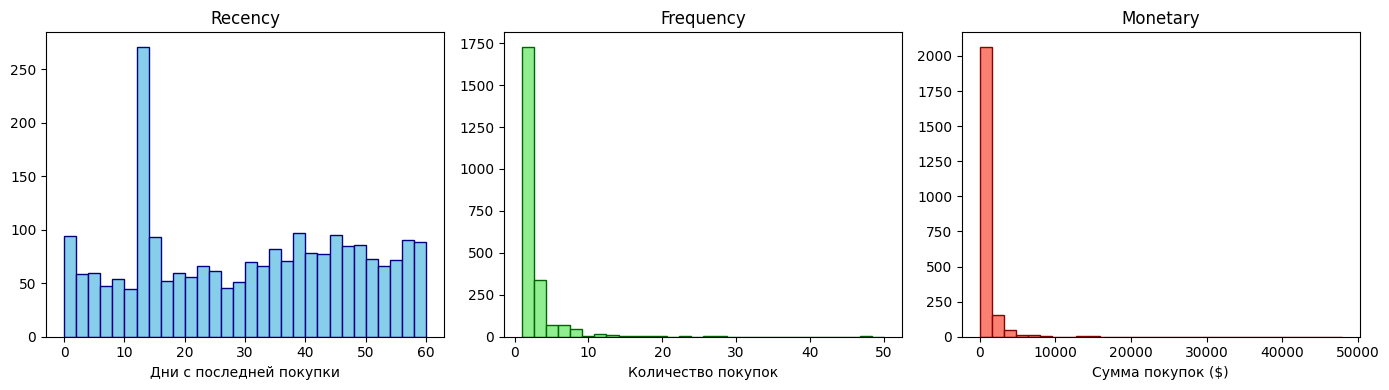

In [ ]:
print('Основные статистические характеристики RFM-метрик:')
display(rfm_df[['recency', 'frequency', 'monetary']].describe())

print('\nРаспределение значений метрик:')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# построим гистограммы распределений значений каждой метрики
# recency
axes[0].hist(rfm_df['recency'], bins=30, color='skyblue', edgecolor='navy')
axes[0].set_title('Recency')
axes[0].set_xlabel('Дни с последней покупки')

# frequency
axes[1].hist(rfm_df['frequency'], bins=30, color='lightgreen', edgecolor='darkgreen')
axes[1].set_title('Frequency')
axes[1].set_xlabel('Количество покупок')

# monetary
axes[2].hist(rfm_df['monetary'], bins=30, color='salmon', edgecolor='darkred')
axes[2].set_title('Monetary')
axes[2].set_xlabel('Сумма покупок ($)')

plt.tight_layout()
plt.show()

Видим, что **Recency** распределен достаточно равномерно, поэтому к этому параметру будем применять стандартное деление на квартили.

Распределения **Frequency** и **Monetary** сильно смещены влево, для их интерпретации потребуется более детальный анализ - построим таблицу процентилей:

In [ ]:
quantiles = [0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
percentiles = rfm_df[['recency', 'frequency', 'monetary']].quantile(quantiles).T
print('Таблица процентилей:')
display(percentiles)

Таблица процентилей:


,0.50,0.75,0.90,0.95,0.99,1.00
recency,31.000,45.00,54.0,57.00,60.0000,60.00
frequency,1.000,3.00,5.0,7.00,17.0000,50.00
monetary,271.385,723.97,1691.4,2792.08,6565.3681,47882.58


Более половины пользователей - one-time покупатели, поэтому по метрике **Frequency** выделим 3 группы:
- пользователей с одной покупкой
- пользователей с 2-5 покупками
- пользователей с 6 и более покупками (10% Frequency)

Также большая часть клиентов тратит мало, и всего несколько клиентов - много тратят, они дают основную выручку, поэтому будет целесообразно применить следующую группировку по **Monetary**:
- пользователи с суммой покупок более 1691\$ (10% Monetary)
- все остальные клиенты

In [ ]:
bins_F = [0, 1, 5, 50]                  # определим границы интервалов для frequency
labels_F = [1, 2, 3]                    # назначаем ранг - чем больше покупок, тем выше
rfm_df['F'] = pd.cut(rfm_df['frequency'], bins=bins_F, labels=labels_F)

bins_M = [0, 1691, 50000]               # определяем границы интервалов для monetary
labels_M = [1, 2]                       # назначаем ранги - чем выше сумма, тем выше
rfm_df['M'] = pd.cut(rfm_df['monetary'], bins=bins_M, labels=labels_M)

# для recency ранги в обратном порядке - чем меньше дней с последней покупки, тем выше ранг
rfm_df['R'] = pd.qcut(rfm_df['recency'], q=4, labels=[4, 3, 2, 1])

# для дальнейших операций сравнения задаем порядок значений в категориальных столбцах R, F, M
rfm_df['R'] = rfm_df['R'].cat.reorder_categories([1, 2, 3, 4], ordered=True)
rfm_df['F'] = rfm_df['F'].cat.reorder_categories([1, 2, 3], ordered=True)
rfm_df['M'] = rfm_df['M'].cat.reorder_categories([1, 2], ordered=True)

print('RFM-матрица:')
display(rfm_df.head())

RFM-матрица:


,user_id,monetary,frequency,recency,F,M,R
0,427908425,74.13,1,54,1,1,1
1,491929644,250.82,1,48,1,1,1
2,492719150,1691.92,1,34,1,2,2
3,502778793,949.29,2,6,2,1,4
4,512364781,1996.66,6,35,3,2,2


## Сегментация пользователей

Далее назначаем сегменты на основе комплексов условий относительно метрик R, F, M:

In [ ]:
conditions = [
    ((rfm_df['R'] >= 3) & (rfm_df['F'] == 3) & (rfm_df['M'] == 2)), # самые активные с большой суммой покупок
    ((rfm_df['R'] >= 3) & (rfm_df['F'] >= 2)),                      # регулярные пользователи
    ((rfm_df['R'] >= 3) & (rfm_df['F'] == 1)),                      # новые пользователи
    ((rfm_df['R'] <= 2) & (rfm_df['F'] >= 2)),                      # "спящие" - раньше были регулярными
    ((rfm_df['R'] <= 2) & (rfm_df['F'] == 1)),                      # потерянные - одна покупка довольно давно
]

choices = [
    'Champions',
    'Loyalists',
    'New',
    'Sleeping',
    'Lost'
]

rfm_df['Segment'] = np.select(conditions, choices, default='Others')
print('Сегментация пользователей:')
display(rfm_df.head())

Сегментация пользователей:


,user_id,monetary,frequency,recency,F,M,R,Segment
0,427908425,74.13,1,54,1,1,1,Lost
1,491929644,250.82,1,48,1,1,1,Lost
2,492719150,1691.92,1,34,1,2,2,Lost
3,502778793,949.29,2,6,2,1,4,Loyalists
4,512364781,1996.66,6,35,3,2,2,Sleeping


Посмотрим на распределение пользователей по сегментам:

In [ ]:
# агрегируем сегменты, задавая логический порядок их сортировки
order = ['Champions', 'Loyalists', 'New', 'Sleeping', 'Lost']
segments = rfm_df.groupby('Segment')['user_id'].count().reset_index()
segments.columns = ['Segment', 'users_counts']
segments['Segment'] = pd.Categorical(segments['Segment'], categories=order, ordered=True)
segments.sort_values('Segment', inplace=True)

# попутно считаем долю сегмента в общем числе пользователей
segments['pct_in_total_users'] = (100 * segments['users_counts'] / users_total).round(2)

print('Распределение пользователей по сегментам:')
display(segments)

Распределение пользователей по сегментам:


,Segment,users_counts,pct_in_total_users
0,Champions,90,3.89
2,Loyalists,586,25.35
3,New,509,22.02
4,Sleeping,372,16.09
1,Lost,755,32.66


Для удобства представим информацию в виде графиков:

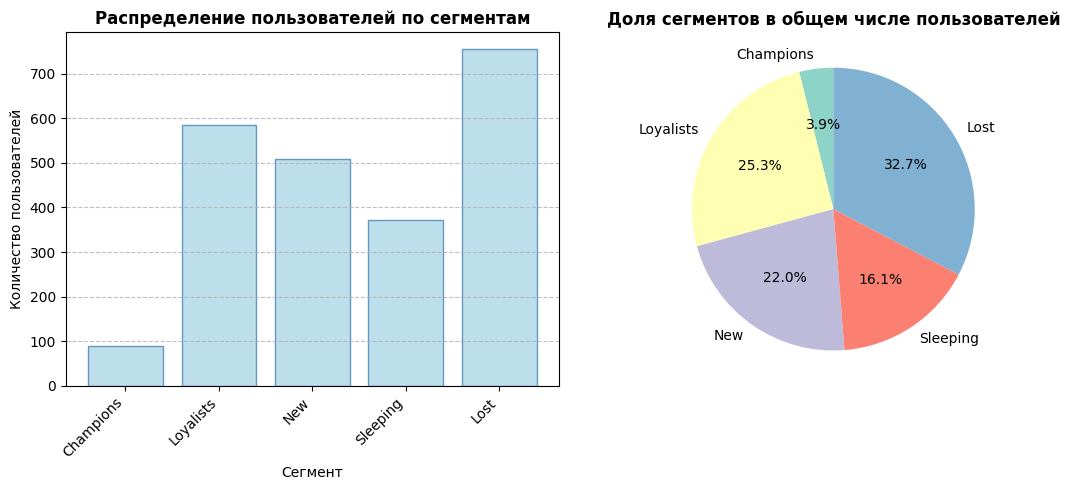

In [ ]:
# построим столбчатую диаграмму для абсолютных цифр
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(segments['Segment'], segments['users_counts'], color='lightblue', edgecolor='steelblue', alpha=0.8)
axes[0].set_title('Распределение пользователей по сегментам', fontweight='bold')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_xlabel('Сегмент')
axes[0].grid(axis='y', linestyle='--', alpha=0.8)
axes[0].set_xticks(list(segments['Segment']))
axes[0].set_xticklabels(segments['Segment'], rotation=45, ha='right')

# и также строим круговую диаграмму для отражения долей сегментов в общем числе пользователей
axes[1].pie(
    segments['pct_in_total_users'],
    labels=segments['Segment'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    textprops={'fontsize': 10}
)
axes[1].set_title('Доля сегментов в общем числе пользователей', fontweight='bold')


plt.tight_layout()
plt.show()

На графике видим:
- Champions составляют всего 3,9% общего числа пользователей, но это самая ценная аудитория - активные пользователи, которые много тратят
- есть стабильное ядро лояльных пользователей - самый большой сегмент (25,3%)
- приток новых пользователей также внушителен (22%)
- "спящие" пользователи (Sleeping) составляют 16,1% общего числа пользователей - эту часть можно реактивировать
- треть (32,7%) пользователей потеряны - но это вполне нормально для e-commerce

## Оценка выручки по сегментам

Дальше посмотрим, какую выручку нам приносят сегменты:

In [ ]:
total_revenue = rfm_df['monetary'].sum() # общая выручка магазина

# агрегируем данные о выручке по сегментам
sales = rfm_df.groupby('Segment')['monetary'].sum().reset_index()
sales.columns = ['Segment', 'segment_revenue']

# находим долю выручки каждого сегмента в общей выручке
sales['pct_in_total_revenue'] = (100 * sales['segment_revenue'] / total_revenue).round(2)
sales['Segment'] = pd.Categorical(sales['Segment'], categories=order, ordered=True)
sales.sort_values('Segment', inplace=True)

print('Сводка по выручке сегментов:')
display(sales)

Сводка по выручке сегментов:


,Segment,segment_revenue,pct_in_total_revenue
0,Champions,463804.10,27.70
2,Loyalists,457191.10,27.31
3,New,139645.32,8.34
4,Sleeping,405303.89,24.21
1,Lost,208191.94,12.44


Также представим информацию наглядно в виде графиков:

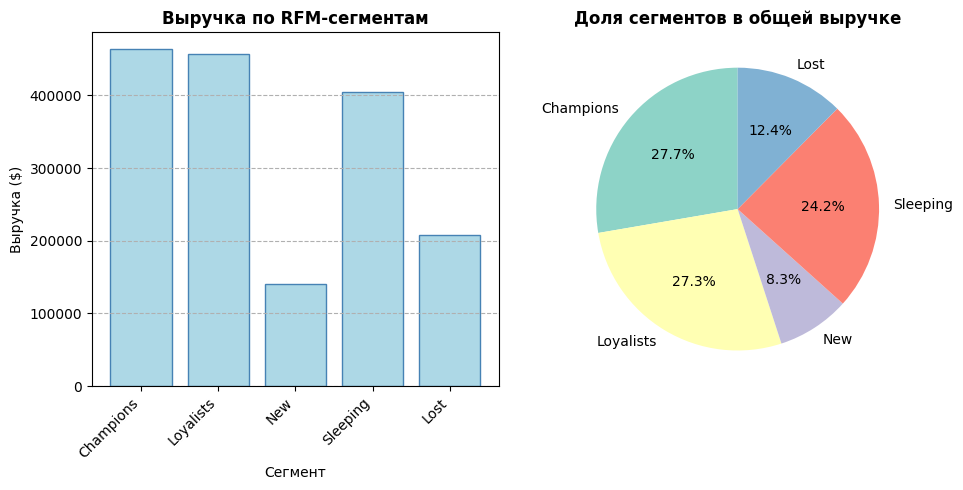

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# аналогично строим столбчатую диаграмму для абсолютных цифр выручки
axes[0].bar(sales['Segment'], sales['segment_revenue'], color='lightblue', edgecolor='steelblue')
axes[0].set_title('Выручка по RFM-сегментам', fontweight='bold')
axes[0].set_xlabel('Сегмент')
axes[0].set_ylabel('Выручка ($)')
axes[0].set_xticks(list(sales['Segment']))
axes[0].set_xticklabels(sales['Segment'], rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--')

# и также аналогично строим круговую диаграмму для долей выручки по сегментам относительно общей выручки
axes[1].pie(
    sales['pct_in_total_revenue'],
    labels=sales['Segment'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors,
    textprops={'fontsize': 10}
)
axes[1].set_title('Доля сегментов в общей выручке', fontweight='bold')

plt.tight_layout()
plt.show()



- Как и ожидалось, самый маленький сегмент Champions приносит нам больше всего денег, их доля в общей выручке составляет (27,7%)
- Лояльные пользователи также приносят 27,3%, это хорошая клиентская база
- 24,2% выручки приносят "спящие" пользователи - почти столько же, сколько лояльные - это большой потенциал роста через реактивацию
- Новые пользователи вкладывают 8.3% в общую выручку, что в целом соответствует ожиданиям, учитывая, что у этих пользователей всего по одной покупке
- Потерянные пользователи принесли 12,4% выручки, что в целом является правдоподобной картиной, так как и покупок у этих пользователей не много

## Итоговые выводы

Объединим все наши полученные результаты в один датафрейм для суммирования выводов

In [ ]:
# объединяем наши датафреймы по ключу Segment
segments_data = pd.merge(
    segments,
    sales,
    on='Segment',
    how='left'
)

display(segments_data)

,Segment,users_counts,pct_in_total_users,segment_revenue,pct_in_total_revenue
0,Champions,90,3.89,463804.10,27.70
1,Loyalists,586,25.35,457191.10,27.31
2,New,509,22.02,139645.32,8.34
3,Sleeping,372,16.09,405303.89,24.21
4,Lost,755,32.66,208191.94,12.44


Таким образом, имеем следующую стратегическую матрицу:

| Сегмент | Доля в общем числе | Доля в общей выручке | Приоритет внимания |
|---------|--------------------|----------------------|-------------|
| Champions | 🔴 Низкая  | 🟢 Высокая | 🔴 Высокий |
| Loyalists | 🟢 Высокая  | 🟢 Высокая | 🟡 Средний |
| New | 🟢 Высокая | 🟡 Средняя | 🟡 Средний |
| Sleeping | 🟡 Средняя | 🟢 Высокая | 🔴 Высокий |
| Lost | 🟡 Средняя | 🔴 Низкая | 🟢 Низкий |

**Рекомендации - фокус на удержании и возвращении ценных пользователей**:
- Champions - удерживать любой ценой: персональные менеджеры, early access, подарки
- лояльные пользователи - удержание + раскрутка, поощрять за повторные покупки, система лояльности
- новые пользователи - улучшить onboarding
- спящие пользователи - главная точка реактивации, их нужно перевести в лояльных
- потерянные пользователи - не трогать, потенциал роста отсутствует + не являются ценными